In [1]:
'''Import modules and load data'''
import sqlite3
import cudf
import pandas as pd
from tqdm import tqdm
import gc
from numba import cuda
import os
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import optuna
import numpy as np
from sklearn.metrics import mean_squared_error
from scipy.special import logit, expit
import lightgbm as lgb



os.chdir('/home/rapids/Capstone')

# From the sqlite data file import into a cudf dataframe the data from the years 2022 and 2023, from months 1 to 5 and from station_id 1 to 496
# def load_data_in_chunks(chunk_size=10000):
#     # Connect to the sqlite database
#     conn = sqlite3.connect('data.sqlite')
#     # Write query
#     query = '''SELECT * FROM data_table WHERE year IN (2022, 2023) AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
#     # Create a generator for chunks
#     for chunk in pd.read_sql_query(query, conn, chunksize=chunk_size):
#         # Convert the pandas chunk to a cudf dataframe
#         yield cudf.DataFrame.from_pandas(chunk)
#     # Close the connection
#     conn.close()

# # Load the data in chunks and process
# df_list = []
# for chunk in tqdm(load_data_in_chunks(chunk_size=10000)):
#     df_list.append(chunk)

# # Concatenate all chunks into a single cudf dataframe
# df = cudf.concat(df_list, ignore_index=True)

# # Print the first 5 rows
# df.head(10)

In [2]:
# # Prepare a second dataframe with the year 2024

# def test_data_in_chunks():
#     # Connect to the sqlite database
#     conn = sqlite3.connect('data.sqlite')
#     # Write query
#     query = '''SELECT * FROM data_table WHERE year = 2024 AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
#     # Create a generator for chunks
#     for chunk in pd.read_sql_query(query, conn, chunksize=10000):
#         # convert the pandas chunk to a cudf dataframe
#         yield cudf.DataFrame.from_pandas(chunk)
#     # Close the connection
#     conn.close()

# # Load the data in chunks and process
# df_list = []
# for chunk in tqdm(test_data_in_chunks()):
#     df_list.append(chunk)

# # Concatenate all chunks into a single cudf dataframe
# test_df = cudf.concat(df_list, ignore_index=True)

# # Print the first 5 rows
# test_df.head(10)

10it [00:00, 44.98it/s]

514it [00:57,  8.94it/s]


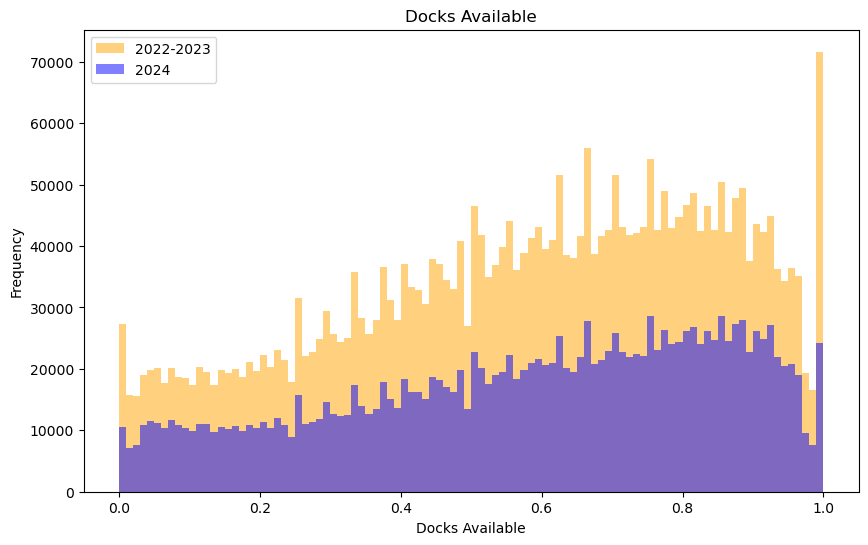

16323

In [3]:
# From the sqlite database, import the docks_available column from the data_table for the years 2022-2024, from months 1 to 5 and from station_id 1 to 496
def target_data_retrieve():
    # Make the connection to the database
    conn = sqlite3.connect('data.sqlite')
    # Write the query
    query = '''SELECT docks_available, year FROM data_table WHERE year IN (2022, 2023, 2024) AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
    # Read the query into a pandas dataframe
    for chunk in pd.read_sql_query(query, conn, chunksize=10000):
        yield pd.DataFrame(chunk)
    # Close the connection
    conn.close()
docks_available = pd.DataFrame()
# Load the data
for chunk in tqdm(target_data_retrieve()):
    docks_available = pd.concat([docks_available, chunk])

# Plot a histogram for the years 2022 and 2023, and another for the year 2024

plt.figure(figsize=(10, 6))
plt.hist(docks_available[docks_available['year'] != 2024]['docks_available'], bins=100, alpha=0.5, label='2022-2023', color='orange')
plt.hist(docks_available[docks_available['year'] == 2024]['docks_available'], bins=100, alpha=0.5, label='2024', color='blue')
plt.legend()
plt.title('Docks Available')
plt.xlabel('Docks Available')
plt.ylabel('Frequency')
plt.show()

# Release memory
del docks_available
gc.collect()

4it [00:00, 31.74it/s]

338it [00:48,  6.91it/s]


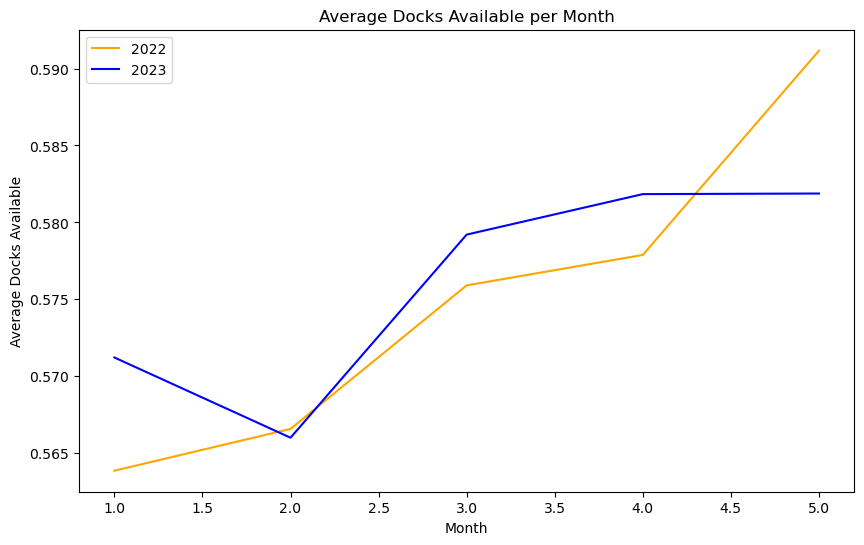

In [4]:
# Import docks_available and timestamp columns from the data_table for the years 2022-2023, from months 1 to 5 and from station_id 1 to 496

def feature_data_retrieve():
    # Make the connection to the database
    conn = sqlite3.connect('data.sqlite')
    # Write the query
    query = '''SELECT docks_available, timestamp, year, month FROM data_table WHERE year IN (2022, 2023) AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
    # Read the query into a pandas dataframe
    for chunk in pd.read_sql_query(query, conn, chunksize=10000):
        yield pd.DataFrame(chunk)
    # Close the connection
    conn.close()

feature_data = pd.DataFrame()

# Load the data
for chunk in tqdm(feature_data_retrieve()):
    feature_data = pd.concat([feature_data, chunk])

# Obtain the average docks_available per month for the years 2022 and 2023
feature_data['timestamp'] = pd.to_datetime(feature_data['timestamp'])
feature_data['month'] = feature_data['timestamp'].dt.month
feature_data['year'] = feature_data['timestamp'].dt.year

# Group by year and month
feature_data = feature_data.groupby(['year', 'month']).agg({'docks_available': 'mean'}).reset_index()

# Plot the average docks_available per month
plt.figure(figsize=(10, 6))
plt.plot(feature_data[feature_data['year'] == 2022]['month'], feature_data[feature_data['year'] == 2022]['docks_available'], label='2022', color='orange')
plt.plot(feature_data[feature_data['year'] == 2023]['month'], feature_data[feature_data['year'] == 2023]['docks_available'], label='2023', color='blue')
plt.legend()
plt.title('Average Docks Available per Month')
plt.xlabel('Month')
plt.ylabel('Average Docks Available')
plt.show()  


# Release memory
del feature_data
gc.collect()
cuda.current_context().deallocations.clear()
cuda.current_context().reset()

In [ ]:
# Repeat the operation for 2024

def feature_data_retrieve():
    # Make the connection to the database
    conn = sqlite3.connect('data.sqlite')
    # Write the query
    query = '''SELECT docks_available, timestamp, year, month FROM data_table WHERE year = 2024 AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
    # Read the query into a pandas dataframe
    for chunk in pd.read_sql_query(query, conn, chunksize=10000):
        yield pd.DataFrame(chunk)
    # Close the connection
    conn.close()

feature_data = pd.DataFrame()

# Load the data
for chunk in tqdm(feature_data_retrieve()):
    feature_data = pd.concat([feature_data, chunk])

# Obtain the average docks_available per month for the year 2024
feature_data['timestamp'] = pd.to_datetime(feature_data['timestamp'])
feature_data['month'] = feature_data['timestamp'].dt.month
feature_data['year'] = feature_data['timestamp'].dt.year

# Group by year and month
feature_data = feature_data.groupby(['year', 'month']).agg({'docks_available': 'mean'}).reset_index()

# Plot the average docks_available per month
plt.figure(figsize=(10, 6))
plt.plot(feature_data[feature_data['year'] == 2024]['month'], feature_data[feature_data['year'] == 2024]['docks_available'], label='2024', color='blue')
plt.legend()
plt.title('Average Docks Available per Month')
plt.xlabel('Month')
plt.ylabel('Average Docks Available')
plt.show()

# Release memory
del feature_data
gc.collect()
cuda.current_context().deallocations.clear()
cuda.current_context().reset()

0it [00:00, ?it/s]

67it [00:09, 16.01it/s]

0it [00:00, ?it/s]

338it [01:22,  4.11it/s]


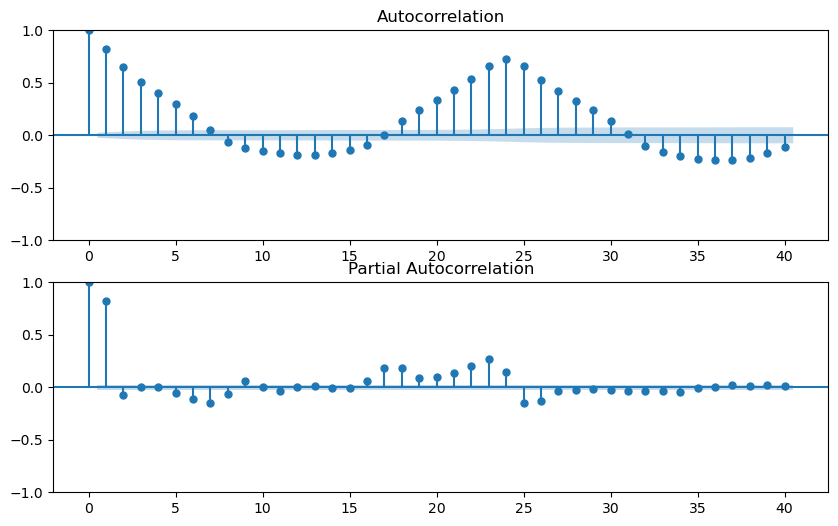

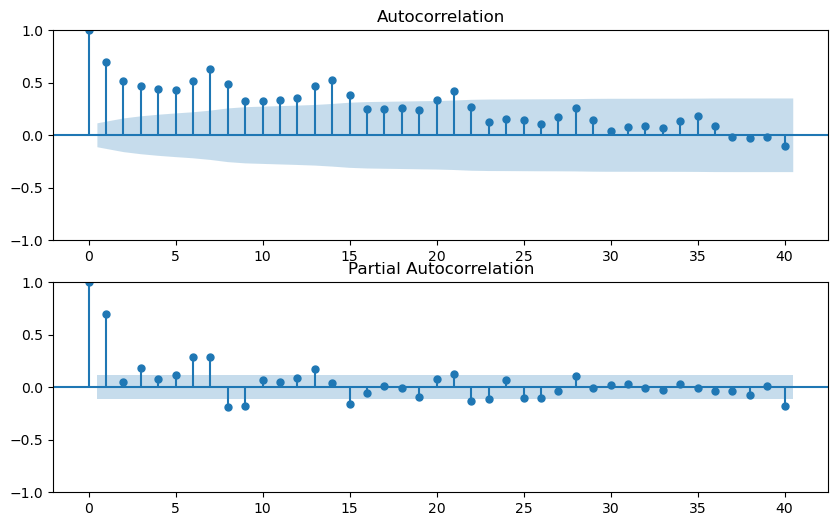

<Figure size 640x480 with 0 Axes>

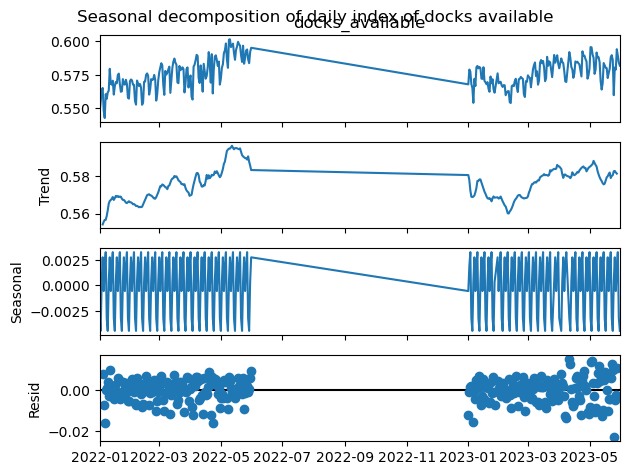

<Figure size 640x480 with 0 Axes>

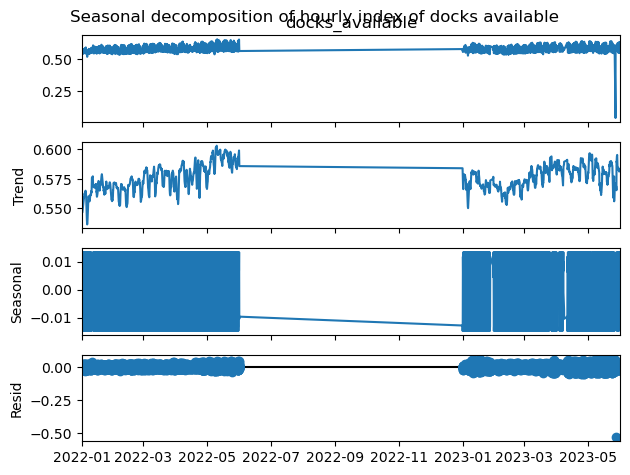

In [ ]:
# Import the following columns from the database
required_columns = ['station_id', 'docks_available', 'timestamp', 'year', 'month', 'day', 'hour', 'temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'wind_speed_10m', 'sunshine_duration']

# Now import from the data_table for the years 2022-2023, from months 1 to 5 and from station_id 1 to 496
def feature_data_retrieve():
    # Make the connection to the database
    conn = sqlite3.connect('data.sqlite')
    # Write the query
    query = '''SELECT station_id, docks_available, timestamp, year, month, day, hour, temperature_2m, apparent_temperature, relative_humidity_2m, wind_speed_10m, sunshine_duration FROM data_table WHERE year IN (2022, 2023) AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
    # Read the query into a pandas dataframe
    for chunk in pd.read_sql_query(query, conn, chunksize=10000):
        yield pd.DataFrame(chunk)
    # Close the connection
    conn.close()

feature_data = pd.DataFrame()

# Load the data
for chunk in tqdm(feature_data_retrieve()):
    feature_data = pd.concat([feature_data, chunk])


# Convert the timestamp column to datetime
feature_data['timestamp'] = pd.to_datetime(feature_data['timestamp'])

# Make timestamp the index
feature_data.set_index('timestamp', inplace=True)

# Resample two dataframes, to hourly and daily
target_data_hourly = feature_data['docks_available'].resample('h').mean()
target_data_daily = feature_data['docks_available'].resample('D').mean()
# Function to plot the ACF and PACF
def plot_acf_pacf(data, lags=40):
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    plot_acf(data.dropna(), lags=lags, ax=ax[0])
    plot_pacf(data.dropna(), lags=lags, ax=ax[1], method='ywm')
    plt.show()

# Plot the ACF and PACF for the hourly data
plot_acf_pacf(target_data_hourly)
plot_acf_pacf(target_data_daily)

'''Seasonal Decomposition'''
# Daily decomposition (period=7 for weekly seasonality)
daily_clean = target_data_daily.dropna()
# Remove months that are not between January and May
daily_clean = daily_clean[(daily_clean.index.month >= 1) & (daily_clean.index.month <= 5)]
decomp_daily = seasonal_decompose(daily_clean, model='additive', period=7)

plt.figure()
decomp_daily.plot()
plt.suptitle('Seasonal decomposition of daily index of docks available')
plt.show()

# Hourly decomposition (period=24 for daily seasonality)
hourly_clean = target_data_hourly.dropna()
# Remove months that are not between 1 and 5
hourly_clean = hourly_clean[(hourly_clean.index.month >= 1) & (hourly_clean.index.month <= 5)]
decomp_hourly = seasonal_decompose(hourly_clean, model='additive', period=24)

plt.figure()
decomp_hourly.plot()
plt.suptitle('Seasonal decomposition of hourly index of docks available')
plt.show()

# Release memory
del feature_data
del target_data_hourly
del target_data_daily
gc.collect()
cuda.current_context().deallocations.clear()
cuda.current_context().reset()




In [3]:
# Import the relevant data from the database
def feature_data_retrieve():
    # Make the connection to the database
    conn = sqlite3.connect('data.sqlite')
    # Write the query
    query = '''SELECT station_id, docks_available, timestamp, year, month, day, hour, temperature_2m, apparent_temperature, relative_humidity_2m, wind_speed_10m, sunshine_duration, rain FROM data_table WHERE year IN (2022, 2024) AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
    # Read the query into a pandas dataframe
    for chunk in pd.read_sql_query(query, conn, chunksize=10000):
        yield pd.DataFrame(chunk)
    # Close the connection
    conn.close()

feature_data = pd.DataFrame()

# Load the data
for chunk in tqdm(feature_data_retrieve()):
    feature_data = pd.concat([feature_data, chunk])

# Convert the timestamp column to datetime
feature_data['timestamp'] = pd.to_datetime(feature_data['timestamp'])

# Make timestamp the index
feature_data.set_index('timestamp', inplace=True)

# Engineer features, four columns which will have docks available shifted by 1, 2, 3, and 4 hours before the current timestamp. They are called ctx-1, ctx-2, ctx-3, and ctx-4
feature_data['ctx-1'] = feature_data['docks_available'].shift(1)
feature_data['ctx-2'] = feature_data['docks_available'].shift(2)
feature_data['ctx-3'] = feature_data['docks_available'].shift(3)
feature_data['ctx-4'] = feature_data['docks_available'].shift(4)

# Drop rows with missing values
feature_data.dropna(inplace=True)

# Sort the data by index (timestamp) and station_id
feature_data.sort_values(by=['station_id'], inplace=True)
feature_data.sort_index(inplace=True)

# Drop columns that are not needed
feature_data.drop(columns=['relative_humidity_2m'], inplace=True)
feature_data.drop(columns=['temperature_2m'], inplace=True)


# Print the first 5 rows
print(feature_data.head(20))

train_set = feature_data[feature_data['year'] < 2024]
test_set = feature_data[feature_data['year'] == 2024]

# Feature list
FEATURES = ['station_id', 'month', 'day', 'hour', 'apparent_temperature', 'rain', 'wind_speed_10m', 'sunshine_duration', 'ctx-1', 'ctx-2', 'ctx-3', 'ctx-4']

TARGET = 'docks_available'

# split the data into features and target
X_train = train_set[FEATURES]
y_train = train_set[TARGET]

X_test = test_set[FEATURES]
y_test = test_set[TARGET]

# Conversion of the specific data to categories
X_train['station_id'] = X_train['station_id'].astype('category')
X_test['station_id'] = X_test['station_id'].astype('category')

# Convert dataframes into cudf
# X_train = cudf.DataFrame.from_pandas(X_train)
# y_train = cudf.Series(y_train)
# X_test = cudf.DataFrame.from_pandas(X_test)
# y_test = cudf.Series(y_test)

# convert y_train and y_test to cupy arrays
# y_train = y_train.to_cupy()
# y_test = y_test.to_cupy()

#Optuna tuning function

def objective(trial):
    # Define the hyperparameters to be tuned
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 1.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 1.0, log=True),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'num_iterations': 1000,
        'early_stopping_round': 100,
        "n_estimators": trial.suggest_int("n_estimators", 200, 3000),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
    }
    # Create the LightGBM dataset
    train_data = lgb.Dataset(X_train, label=y_train)
    valid_data = lgb.Dataset(X_test, label=y_test)
    # Train the model
    model = lgb.LGBMRegressor(**params)
    # Apply logit transformation to the target
    y_train_logit = logit(y_train.clip(1e-6, 1-1e-6))
    # Convert to a cudf series
    # y_train_logit = cudf.Series(y_train_logit)
    # Fit the model
    model.fit(X_train, y_train_logit, eval_set=[(X_test, y_test)], eval_metric='rmse', callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)])

    # Predict the test set
    y_pred_logit = model.predict(X_test)
    # Apply expit transformation to the predictions
    y_pred = expit(y_pred_logit)

    # Calculate the RMSE
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    return rmse

# Trial tracking
def trial_callback(study, trial):
    print('Trial {} finished with value: {}'.format(trial.number, trial.value))

# run Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5, callbacks=[trial_callback], show_progress_bar=True)

# Get the best parameters
best_params = study.best_params
print(best_params)

# Release memory
del feature_data
gc.collect()
cuda.current_context().deallocations.clear()
cuda.current_context().reset()

352it [00:58,  6.01it/s]


            station_id  docks_available  year  month  day  hour  \
timestamp                                                         
2022-01-01         278         0.530864  2022      1    1     0   
2022-01-01         424         0.500000  2022      1    1     0   
2022-01-01         271         0.733333  2022      1    1     0   
2022-01-01         464         0.916667  2022      1    1     0   
2022-01-01         246         0.819444  2022      1    1     0   
2022-01-01         297         0.541667  2022      1    1     0   
2022-01-01          12         0.442308  2022      1    1     0   
2022-01-01         111         0.192982  2022      1    1     0   
2022-01-01         487         1.000000  2022      1    1     0   
2022-01-01         393         0.598958  2022      1    1     0   
2022-01-01         203         0.545455  2022      1    1     0   
2022-01-01          15         0.135802  2022      1    1     0   
2022-01-01         364         0.462121  2022      1    1     

/tmp/ipykernel_41/1302294660.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['station_id'] = X_train['station_id'].astype('category')
/tmp/ipykernel_41/1302294660.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['station_id'] = X_test['station_id'].astype('category')
[I 2025-03-26 22:30:32,358] A new study created in memory with name: no-name-42a88201-4d5f-475d-8eb0-1c2652801fd4


  0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Warning] min_data_in_leaf is set=62, min_child_samples=90 will be ignored. Current value: min_data_in_leaf=62
[LightGBM] [Warning] feature_fraction is set=0.7269297465458688, colsample_bytree=0.8585522711253886 will be ignored. Current value: feature_fraction=0.7269297465458688
[LightGBM] [Warning] lambda_l2 is set=3.7182908571192498e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=3.7182908571192498e-06
[LightGBM] [Warning] lambda_l1 is set=4.871076083716428e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=4.871076083716428e-08
[LightGBM] [Warning] bagging_fraction is set=0.7775731873716574, subsample=0.9936575446062583 will be ignored. Current value: bagging_fraction=0.7775731873716574
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin 

[LightGBM] [Warning] min_data_in_leaf is set=36, min_child_samples=39 will be ignored. Current value: min_data_in_leaf=36
[LightGBM] [Warning] feature_fraction is set=0.8282784157283751, colsample_bytree=0.7466991299251277 will be ignored. Current value: feature_fraction=0.8282784157283751
[LightGBM] [Warning] lambda_l2 is set=1.0846410611470654e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0846410611470654e-06
[LightGBM] [Warning] lambda_l1 is set=7.225245939523677e-06, reg_alpha=0.0 will be ignored. Current value: lambda_l1=7.225245939523677e-06
[LightGBM] [Warning] bagging_fraction is set=0.523573118859507, subsample=0.7751997650852065 will be ignored. Current value: bagging_fraction=0.523573118859507
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin an

<Figure size 1000x600 with 0 Axes>

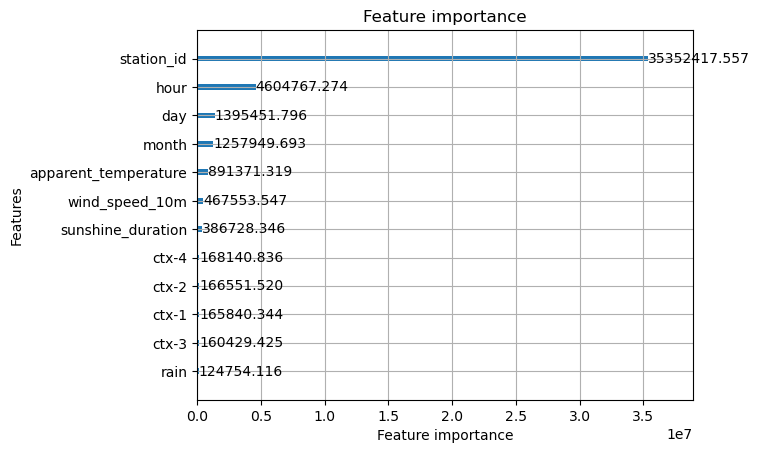

In [4]:
# Train the model with the best parameters
model = lgb.LGBMRegressor(**best_params)
model.fit(X_train, logit(y_train.clip(1e-6, 1-1e-6)))

# Predict the test set
y_pred = model.predict(X_test)

# Calculate the RMSE
rmse = mean_squared_error(y_test, expit(y_pred)) ** 0.5
print('RMSE:', rmse)

# Plot the feature importance
plt.figure(figsize=(10, 6))
lgb.plot_importance(model, importance_type='gain')
plt.show()